# Temperature Trends MPI SSP 245 (GCM & MAR-GCM)
#  (Annual and Seasonnal  -original)

## 1. Environnement

In [1]:
# import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path

from scipy.stats import linregress

#import geopandas as gpd
from pyproj import Proj, transform
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import shapefile
from copy import copy

/Users/peyaudv/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'

In [3]:
def get_slopes_and_pvalue_year(wp_meanyear):

    wp_meanyear_hist = wp_meanyear[:86,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanyear.shape[2]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanyear.shape[1]):
            #for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanyear_hist.shape[0]), wp_meanyear_hist[:,j,i])
                origin_hist[j][i] = linregress_hist.intercept
                slope_hist[j][i] = linregress_hist.slope
                pvalue_hist[j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

In [4]:
def get_slopes_and_pvalue_seas(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:86,:,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

In [5]:
def get_slopes_and_pvalue_mon(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:86,:,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:12],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:12],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:12],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(12): # not seasons but months
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

## 2. SSP 245

In [6]:
GCMname = 'MPI'
scenario = 'SSP245' #'HIST' #

varnameShort = 'Temp'
varnameLong = 'Temperature'

In [103]:
zoom = False
#zoom=True

### 2.0 load Data

In [8]:
wp_mean_var_GCM = np.load(path_DIR+'numpyData/tas_MPI-ESM1-2-HR_SSP245'+'.npz')

In [9]:
print(wp_mean_var_GCM)

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/tas_MPI-ESM1-2-HR_SSP245.npz' with keys: T_month, T_season, T_year, lon, lat...


In [10]:
yearG=wp_mean_var_GCM['years']
longG=wp_mean_var_GCM['lon']
latiG=wp_mean_var_GCM['lat']
tmonG =wp_mean_var_GCM['T_month']
tsaiG =wp_mean_var_GCM['T_season']
tyeaG =wp_mean_var_GCM['T_year']

In [11]:
wp_mean_var_GCM

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/tas_MPI-ESM1-2-HR_SSP245.npz' with keys: T_month, T_season, T_year, lon, lat...

In [12]:
print(tsaiG.shape)

(86, 4, 7, 14)


In [13]:
wp_mean_var_MAR = np.load(path_DIR+'numpyData/ttz_MARMPI-ESM_SSP245'+'.npz')

In [14]:
wp_mean_var_MAR['T_season'].shape

(86, 4, 91, 139)

In [15]:
yearM=wp_mean_var_MAR['years']
longM=wp_mean_var_MAR['lon']
latiM=wp_mean_var_MAR['lat']
tmonM =wp_mean_var_MAR['T_month']
tsaiM =wp_mean_var_MAR['T_season']
tyeaM =wp_mean_var_MAR['T_year']
#print(yearM)

In [16]:
WantedMassifPatches=[]
# Download and unzip shapefiles and open the desired one
shapes = shapefile.Reader("s2m_shapefiles/massifs_shapefiles/massifs_alpes_4226.shp")
patches = []
for shape in shapes.shapeRecords():
    massif_number = shape.record[0]
    massif_name = shape.record[1]
    polygon = Polygon(shape.shape.points, ec="none", fc="y", alpha=0.9)#, fill=False,facecolor='None')
    #print(shape.shape.points)
    patches.append(polygon)
    
    #print(shape.record[0],shape.record[1])
    if (massif_name=='Mont-Blanc'): 
        print(massif_name, massif_number)
        polygon_MB = Polygon(shape.shape.points, ec="none", fc="b", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Vanoise'): 
        print(massif_name, massif_number)
        polygon_VA = Polygon(shape.shape.points, ec="none", fc="r", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Oisans'): 
        print(massif_name, massif_number)
        polygon_OI = Polygon(shape.shape.points, ec="none", fc="g", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Mont-Blanc' or massif_name=='Vanoise' or massif_name=='Oisans'):
        WantedMassifPatches.append([massif_name, massif_number])
print(WantedMassifPatches)

Mont-Blanc 3
Vanoise 10
Oisans 15
[['Mont-Blanc', 3], ['Vanoise', 10], ['Oisans', 15]]


### Find Glacioclim XY position

In [17]:
def findXYGlacioclim2 (lonGla,latGla,lonGrid2d,latGrid2d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid2d-latGla)
    abslon = np.abs(lonGrid2d-lonGla)
    c = np.maximum(abslon, abslat)
    # Return the grid point coordinates (x,y)
    ([xloc], [yloc]) = np.where(c == np.min(c))
    return (xloc, yloc) #([xloc], [yloc])

def findXYGlacioclim1 (lonGla,latGla,lonGrid1d,latGrid1d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid1d-latGla)
    abslon = np.abs(lonGrid1d-lonGla)
    xloc,yloc = np.where(abslon == np.min(abslon)), np.where(abslat == np.min(abslat))
    return (xloc[0].item(),yloc[0].item())#(xloc, yloc) #([xloc], [yloc])
    # use xloc[0].item() because np.where returns an ndarray

# Glacioclim glaciers location study (lon lat)
glacioClim=[["Argentiere",6.93,45.9], ["Mer de Glace",6.97,45.95], ["Gebroulaz",6.61,45.28], ["Saint Sorlin",6.63,45.15], ["Glacier Blanc",6.37,44.93]]

In [18]:
# X Y coordinates in MAR Grid 
glacioClXYG=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]
glacioClXYM=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]

for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    glacioClXYG[i][1],glacioClXYG[i][2] = findXYGlacioclim1(glacioClim[i][1],glacioClim[i][2],longG,latiG)
    glacioClXYM[i][1],glacioClXYM[i][2] = findXYGlacioclim2(glacioClim[i][1],glacioClim[i][2],longM,latiM)

In [19]:
print(glacioClXYG)

[['Argentiere', 3, 4], ['Mer de Glace', 3, 4], ['Gebroulaz', 3, 3], ['Saint Sorlin', 3, 3], ['Glacier Blanc', 3, 3]]


### 2.1 Plot (define colormap & range )

In [20]:
# Color scale Temp
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

In [21]:
if ((yearM[0]!=yearG[0])or(len(yearM)!=len(yearG))):
    print ("WARNING : yearM and yearG are different")
#print(yearM)
#print(yearG)

In [22]:
year1,year2=0,80
date1,date2=int(yearG[0]+year1), int(yearG[0]+year2)

if (yearG[0]+year1 != yearM[0]+year1):
        print ('WARNING : date1M and date1G are different')

### 2.2 Plot january temperature (selected years)

Polygon43((6.17888, 45.8492) ...)


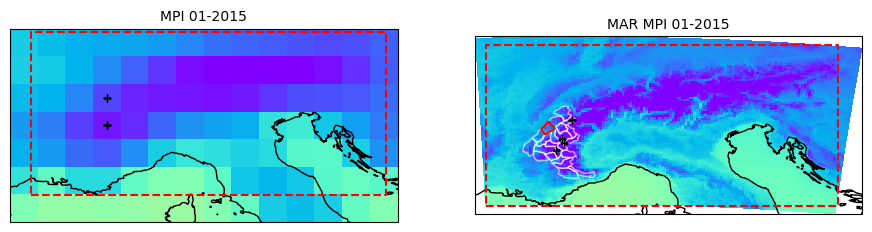

In [23]:
# Plot temperature pour 1er mois (january)
fig, axs = plt.subplots(1, 2, figsize=(11, 3),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0].set_title(f'{GCMname} 01-{date1}',fontsize=10)
axs[1].set_title(f'MAR {GCMname} 01-{date1}',fontsize=10)

# pcolormesh
m = axs[0].pcolormesh(
    longG, latiG, tmonG[year1,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1].pcolormesh(
    longM, latiM, tmonM[year1,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

for i, ax in enumerate(axs):
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
   ax.add_feature(cfeature.COASTLINE)
#axs[1].add_feature(cfeature.COASTLINE)

# Tracé du polygone en pointillés rouge
   ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('w')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[1].add_collection(collection)

#Massif Mont Blanc
print(patches[3])
axs[1].plot(patches[3].get_xy()[:, 0],patches[3].get_xy()[:, 1],color='red')

In [24]:
print(glacioClXYM[i][2])

28


### 2.3 Plot annual temperature (selected years)

Polygon43((6.17888, 45.8492) ...)
14


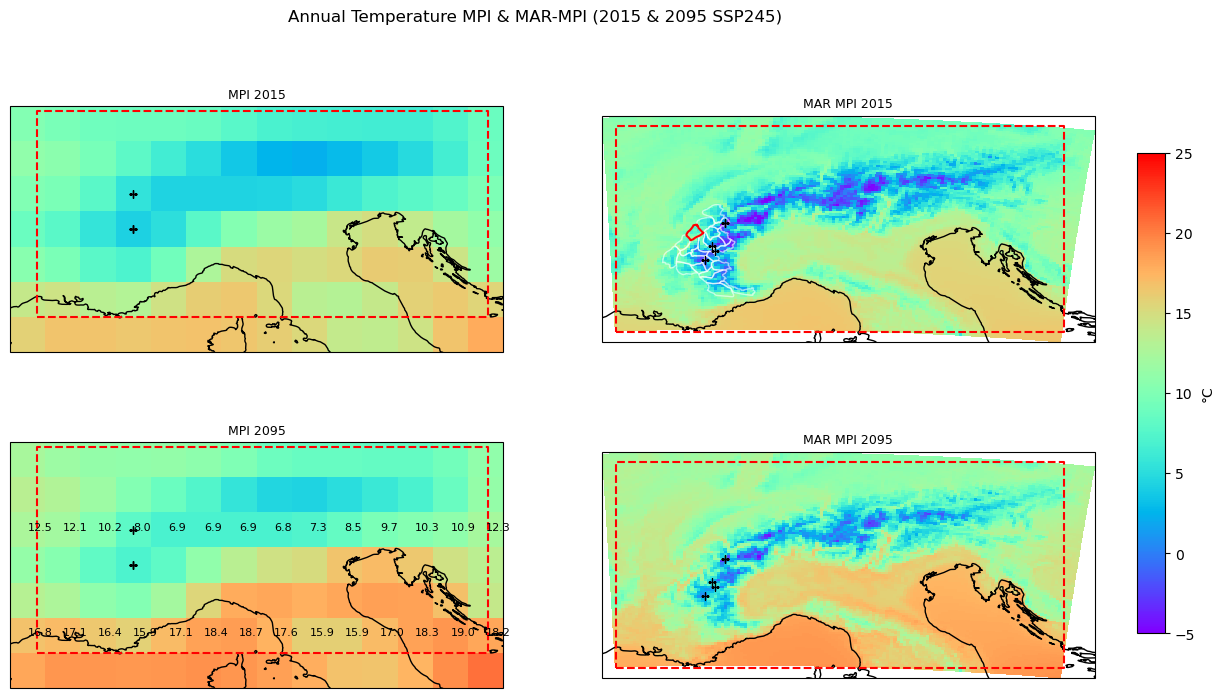

In [25]:
# Plot temperature pour 1er mois
fig, axs = plt.subplots(2, 2, figsize=(14, 8),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0,0].set_title(f"{GCMname} {date1}",fontsize=9)
axs[0,1].set_title(f"MAR {GCMname} {date1}",fontsize=9)
axs[1,0].set_title(f"{GCMname} {date2}",fontsize=9)
axs[1,1].set_title(f"MAR {GCMname} {date2}",fontsize=9)

# pcolormesh
m = axs[0,0].pcolormesh(
    longG, latiG, tyeaG[year1],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[0,1].pcolormesh(
    longM, latiM, tyeaM[year1],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
# pcolormesh
m = axs[1,0].pcolormesh(
    longG, latiG, tyeaG[year2],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1,1].pcolormesh(
    longM, latiM, tyeaM[year2],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

axs[0,0].add_feature(cfeature.COASTLINE)
axs[0,1].add_feature(cfeature.COASTLINE)
axs[1,0].add_feature(cfeature.COASTLINE)
axs[1,1].add_feature(cfeature.COASTLINE)
axs[0,0].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[0,1].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[1,0].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[1,1].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
#for i, ax in enumerate(axs):
#   ax.add_feature(cfeature.COASTLINE) # Does not work
   # Tracé du polygone en pointillés rouge
   #ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r')#, transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0,0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[0,1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')
    axs[1,0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1,1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')
# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('w')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[0,1].add_collection(collection)

#Massif Mont Blanc
print(patches[3])
axs[0,1].plot(patches[3].get_xy()[:, 0],patches[3].get_xy()[:, 1],color='red')
# Horizontal colorbar
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
fig.colorbar(m, cax=cbar_ax, orientation='vertical', label='°C')

############
print(longG.shape[0])
for jj in range(longG.shape[0]): # loop on lon (line of longitude)
    axs[1,0].text(longG[jj],latiG[4],f'{tyeaG[year2,4,jj]:.1f}',fontsize=8) # !!!! = tyeaG[year,lat,lon]
    axs[1,0].text(longG[jj],latiG[1],f'{tyeaG[year2,1,jj]:.1f}',fontsize=8) # !!!! = tyeaG[year,lat,lon]

fig.suptitle(f"Annual {varnameLong} {GCMname} & MAR-{GCMname} ({date1} & {date2} {scenario})", fontsize=12)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_years_{date1}and{date2}.png")

In [26]:
# print year 2 GCM
print(f'{tyeaG[year2,-2,:]}') # ligne la plus froide avec alpes suisses
print(tyeaG[year2,5,:])       # idem
print()
print(tyeaG[year2,4,:]) # ligne mont blanc 
print(tyeaG[year2,4,2]) # i-1,j
print(tyeaG[year2,4,3]) # Mont Blanc i,j
print(tyeaG[year2,4,7]) # i+1,j

[13.2890625  12.84844971 11.73599243 10.16421509  8.72509766  7.31265259
  5.65576172  4.49688721  4.31542969  4.97817993  5.90313721  6.92007446
  8.65283203 11.20147705]
[13.2890625  12.84844971 11.73599243 10.16421509  8.72509766  7.31265259
  5.65576172  4.49688721  4.31542969  4.97817993  5.90313721  6.92007446
  8.65283203 11.20147705]

[12.4631958  12.07226562 10.20800781  7.98321533  6.93066406  6.8984375
  6.85025024  6.84228516  7.3019104   8.45587158  9.65362549 10.28839111
 10.87109375 12.3303833 ]
10.2080078125
7.98321533203125
6.84228515625


### 2.4 Plot seasonal temperature (selected years)

In [27]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]

2015


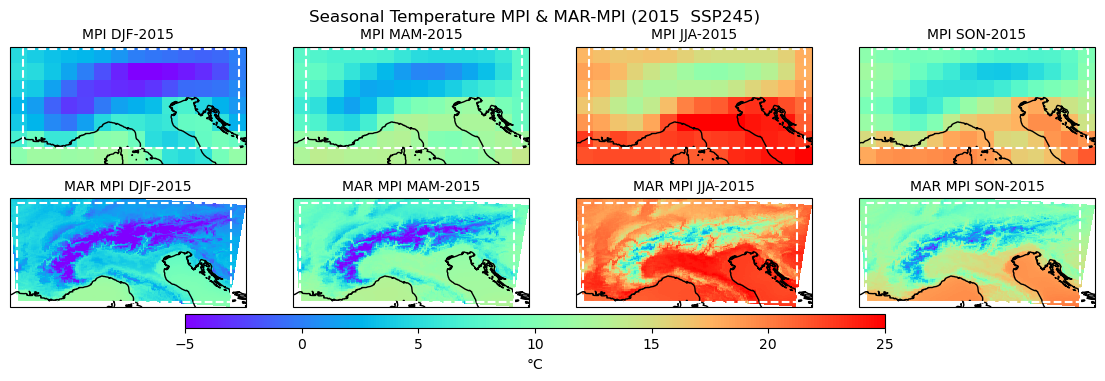

In [28]:
# Plot temperature for date1
date=date1
year=year1
print(date)

fig, axs = plt.subplots(2, 4, figsize=(14, 3.5),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

for s in range(len(labelseasons)):
    #print(i,saisons[i])
    # ----- GCM -----
    ax = axs[0, s]
    ax.set_title(f'{GCMname} {labelseasons[s]}-{date}',fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, tsaiG[year,s],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- MAR -----
    ax = axs[1, s]
    ax.set_title(f'MAR {GCMname} {labelseasons[s]}-{date}',fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longM, latiM, tsaiM[year,s],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

fig.suptitle(f'Seasonal {varnameLong} {GCMname} & MAR-{GCMname} ({date}  {scenario})', fontsize=12)
plt.savefig(f'{path_IMG}{GCMname}_{scenario}_{varnameShort}_season_{date}.png')

2095


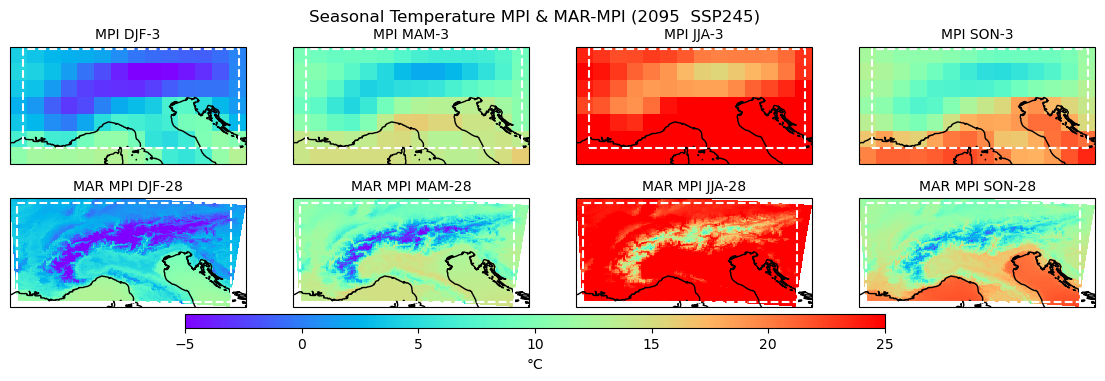

In [29]:
# Plot temperature for date2
date=date2
year=year2
print(date)

fig, axs = plt.subplots(2, 4, figsize=(14, 3.5),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

for i in range(len(labelseasons)):
    #print(i,saisons[i]) 
    # ----- GCM -----
    ax = axs[0, i]
    ax.set_title(f'{GCMname} {labelseasons[i]}-{yG}',fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, tsaiG[year,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- MAR -----
    ax = axs[1, i]
    ax.set_title(f'MAR {GCMname} {labelseasons[i]}-{yM}',fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longM, latiM, tsaiM[year,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')
fig.suptitle(f"Seasonal {varnameLong} {GCMname} & MAR-{GCMname} ({date2}  {scenario})", fontsize=12)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_season_{date2}.png")

### 2.5 Plot annual temperature trends

In [30]:
# Annual Temperature trend for GCM
slopeT_yG, pvalue_yG = get_slopes_and_pvalue_year(tyeaG)

In [31]:
print(slopeT_yG.shape) # seasons, lon, lat

(7, 14)


In [32]:
# Seasonnal  Temperature trend for MAR
slopeT_yM, pvalue_yM = get_slopes_and_pvalue_year(tyeaM)

In [33]:
print(slopeT_yM.shape) # seasons, lon, lat

(91, 139)


In [104]:
# Color scale Temp
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'hot_r'
vmin_scale, vmax_scale = 0., 5.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=vmin_scale, vmax=vmax_scale)
# Proj
proj = ccrs.PlateCarree()
quality = 100

In [105]:
if zoom:
    LxPlot, LyPlot, iszoom = 10, 5  ,'_zoom'
else :
    LxPlot, LyPlot, iszoom = 12, 3.5,''

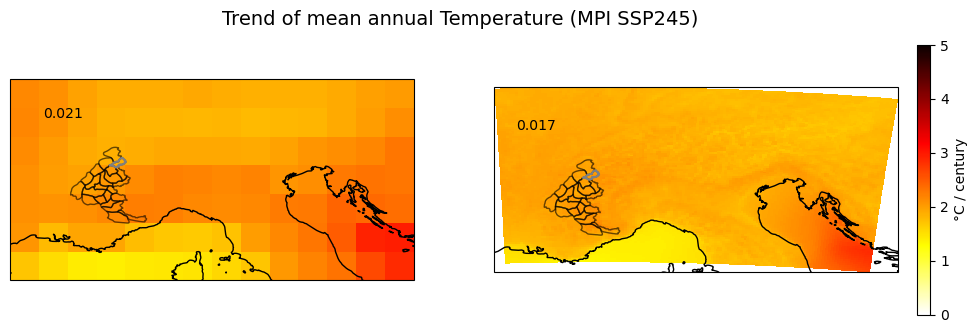

In [106]:
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(LxPlot, LyPlot),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)

# ----- GCM -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
cb = ax.pcolormesh(longG, latiG, 100*slopeT_yG, # 100*slope_T_hist[i] ????????
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5, 47.5, f"{np.mean(slopeT_yG[i]):.3f}",
        ha='center', va='center', fontsize=10)
if (zoom):
    ax.set_xlim(5,8)
    ax.set_ylim(43.5,47)
    ax.text(5.7, 46.8, f"{np.mean(slopeT_yG[i]):.3f}°C/centuries",
            ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, 100*slopeT_yM,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5, 47.5, f"{np.mean(slopeT_yM[i]):.3f}",
            ha='center', va='center', fontsize=10)
if (zoom):
    ax.set_xlim(5,8)
    ax.set_ylim(43.5,47)
    ax.text(5.7, 46.8, f"{np.mean(slopeT_yM[i]):.3f}°C/centuries",
            ha='center', va='center', fontsize=10)
    axs[1].text(6.5,46.1,"Massif Mont Blanc",color='gray')
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
axs[1].set_ylabel(label, fontsize=14, rotation=90)

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('k')
    collection.set_alpha(0.6)
    axs[0].add_collection(collection)
    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection1 = PatchCollection(new_patches)
    collection1.set_color('none')
    collection1.set_edgecolor('k')
    collection1.set_alpha(0.6)
    axs[1].add_collection(collection1)

# Plot Mont Blanc in red
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')

fig.suptitle(f"Trend of mean annual {varnameLong} ({GCMname} {scenario})", fontsize=14)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_Trend_year{iszoom}.png")

In [37]:
i=1 #MdG
xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]

print(f'i,j,Temperature trend GCM at {glacioClXYG[i][0]}')
print(xG,yG,100*slopeT_yM[xG,yG])
print(xG,yG,100*slopeT_yM[xG+1,yG])

i,j,Temperature trend GCM at Mer de Glace
3 4 1.4924290659427752
3 4 1.5011417389455857


### 2.6 Plot seasonal temperature trends

In [38]:
# Seasonnal Temperature trend for GCM
slopeT_sG, pvalue = get_slopes_and_pvalue_seas(tsaiG)

In [39]:
print(slopeT_sG.shape) # seasons, lon, lat

(4, 7, 14)


In [40]:
# Seasonnal  Temperature trend for MAR
slopeT_sM, pvalue = get_slopes_and_pvalue_seas(tsaiM)

In [41]:
print(slopeT_sM.shape) # seasons, lon, lat

(4, 91, 139)


In [107]:
if zoom:
    LxPlot, LyPlot, iszoom = 10, 5  ,'_zoom'
else :
    LxPlot, LyPlot, iszoom = 14, 3.5,''

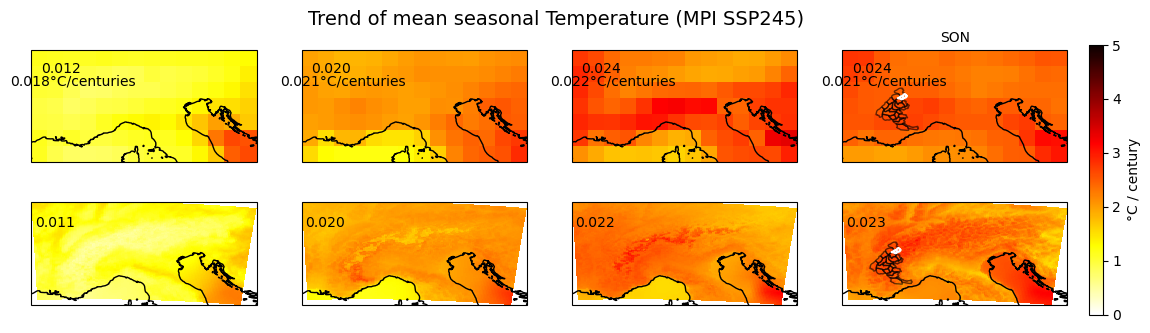

In [108]:
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=2, ncols=4,figsize=(LxPlot, LyPlot),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)
# Color scale
colo_scale = 'Oranges'#'coolwarm'
colo_scale = 'hot_r'
vmin_scale, vmax_scale = 0., 5. #-5., 5.
#levels = np.linspace(0, 8, 65)

# Boucle principale
for s in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

    # ----- GCM -----
    ax = axs[0, s]
    #print("hist",slope_T_hist[i,0,0])
    cb = ax.pcolormesh(longG, latiG, 100*slopeT_sG[s], # 100*slope_T_hist[i] ????????
                       cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5, 47.5, f"{np.mean(slopeT_sG[s]):.3f}",
            ha='center', va='center', fontsize=10)
    if (zoom):
        ax.set_xlim(5,8)
        ax.set_ylim(43.5,47)
        ############# write values around MdG ####
        print(s,slopeT_sG[s, glacioClXYG[1][2],glacioClXYG[1][1]])
        for ii in np.arange(-1,2):
            for jj in np.arange(-1,2):
                ilat, jlon = glacioClXYG[1][1]+ii, glacioClXYG[1][2]+jj 
                ax.text(longG[ilat], latiG[jlon], f'{100*slopeT_sG[s,jlon,ilat]:.2f}',fontsize=8)
    ax.text(5.7, 46.8, f"{np.mean(slopeT_yG[s]):.3f}°C/centuries",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)
    
    # ----- MAR -----
    ax = axs[1, s]
    #print("245",slope_T_245[i,0,0])
    ax.pcolormesh(longM, latiM, 100*slopeT_sM[s],
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5, 47.5, f"{np.mean(slopeT_sM[s]):.3f}",
            ha='center', va='center', fontsize=10)
    if (zoom):
        ax.set_xlim(5,8)
        ax.set_ylim(43.5,47)
    ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
for i, label in enumerate(["DJF", "MAM", "JJA", "SON"]):
    axs[0, s].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i, 0].yaxis.set_ticks_position('right')
    axs[i, 0].set_ylabel(label, fontsize=14, rotation=90)
axs[1, 1].set_ylabel(label, fontsize=14, rotation=90)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0,3].add_collection(collection2)
axs[1,3].add_collection(collection3)
# Plot Mont Blanc in white
i_ployg=2 
axs[0,3].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')
axs[1,3].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')

fig.suptitle(f"Trend of mean seasonal {varnameLong} ({GCMname} {scenario})", fontsize=14)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_Trend_season{iszoom}.png")

In [44]:
### Print info (debuging)
jrange=np.arange(-1,2)
print(jrange)
print(f'GCM {varnameShort} Trend {glacioClXYG[1][0]} and neigbhourg:')
    #glacioClXYG[i][1]  
for i in np.arange(-1,2):
    print(glacioClXYG[1][1]+i,glacioClXYG[1][2]+jrange)

for s, label in enumerate(["DJF", "MAM", "JJA", "SON"]):
    print(label)
    for i in np.arange(-1,2):
        print(slopeT_sG[s, glacioClXYG[1][1]+i,glacioClXYG[1][2]+jrange])    

[-1  0  1]
GCM Temp Trend Mer de Glace and neigbhourg:
2 [3 4 5]
3 [3 4 5]
4 [3 4 5]
DJF
[0.00955293 0.01102088 0.01214465]
[0.00842764 0.0093497  0.00937667]
[0.00751605 0.00770116 0.00848091]
MAM
[0.02120857 0.02073515 0.02007382]
[0.02195306 0.02128759 0.02056043]
[0.02019725 0.02036888 0.02022441]
JJA
[0.0288367  0.03035749 0.03017889]
[0.02532484 0.02811069 0.03172532]
[0.02204966 0.02288977 0.02387321]
SON
[0.0266162  0.02701034 0.02629186]
[0.02600032 0.02664864 0.0271632 ]
[0.02451491 0.02470646 0.02472202]


### 2.7 Plot monthly trends

In [132]:
tmonG.shape

(86, 12, 7, 14)

In [133]:
# Monthly trend for GCM
slopeT_mG, pvalue = get_slopes_and_pvalue_mon(tmonG)

print(slopeT_mG.shape) # seasons, lon, lat

# Monthly trend for MAR
slopeT_mM, pvalue = get_slopes_and_pvalue_mon(tmonM)

print(slopeT_mM.shape) # seasons, lon, lat

(12, 7, 14)
(12, 91, 139)


In [134]:
labelmonths = ["Jan", "Feb", "Mar", "Ap", "May","Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

### 2.7.1 Plot variable (months)

In [135]:
# Color scale Temp
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.

In [136]:
zoom=False
if zoom:
    iszoom, widthPlot = '_zoom',7
else :
    iszoom, widthPlot = '',12

0 0 Jan
0 1 Feb
0 2 Mar
0 3 Ap
2 0 May
2 1 Jun
2 2 Jul
2 3 Aug
4 0 Sep
4 1 Oct
4 2 Nov
4 3 Dec


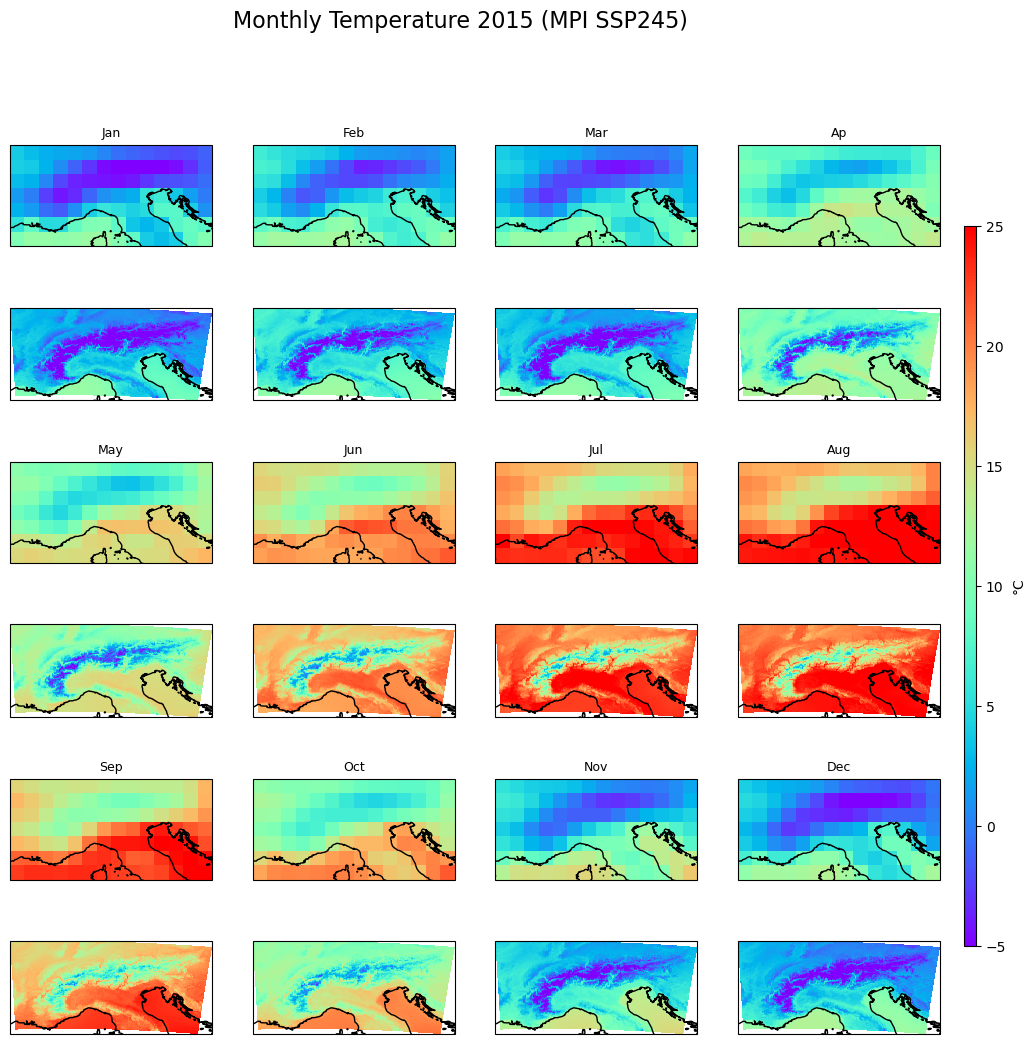

In [137]:
fig, axs = plt.subplots(6, 4, figsize=(widthPlot, 12),subplot_kw={'projection': proj},dpi=quality) 
m=0    

for i in range(0,6,2): # lines
    for j in range(4): #columns
        ax = axs[i,j]
        print(i,j,labelmonths[m])
        ax.set_title(f"{labelmonths[m]}",fontsize=9)
        # GCM
        f = ax.pcolormesh(
            longG, latiG, tmonG[year1,m],
            cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
        )
        if (zoom):
            ax.set_xlim(5,8)
            ax.set_ylim(43.5,47)
        ax.add_feature(cfeature.COASTLINE)
        # MAR
        ax = axs[i+1,j]
        f = ax.pcolormesh(
            longM, latiM, tmonM[year1,m],
            cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
        )
        ax.add_feature(cfeature.COASTLINE)
        if (zoom):
            ax.set_xlim(5,8)
            ax.set_ylim(43.5,47)
        m=m+1
# ----- Colorbar -----
# Horizontal colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.01, 0.6])
fig.colorbar(f, cax=cbar_ax, orientation='vertical', label='°C')
        
fig.suptitle(f"Monthly {varnameLong} {date1} ({GCMname} {scenario})", fontsize=16)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_month{iszoom}.png")

### 2.7.2 Plot trend (months)

In [144]:
# Color scale Temp
colo_scale = 'hot_r'
vmin_scale, vmax_scale = 0., 5.

In [158]:
zoom = True
if zoom:
    iszoom, widthPlot = '_zoom',7
else :
    iszoom, widthPlot = '',12

0 0 Jan
0 1 Feb
0 2 Mar
0 3 Ap
2 0 May
2 1 Jun
2 2 Jul
2 3 Aug
4 0 Sep
4 1 Oct
4 2 Nov
4 3 Dec


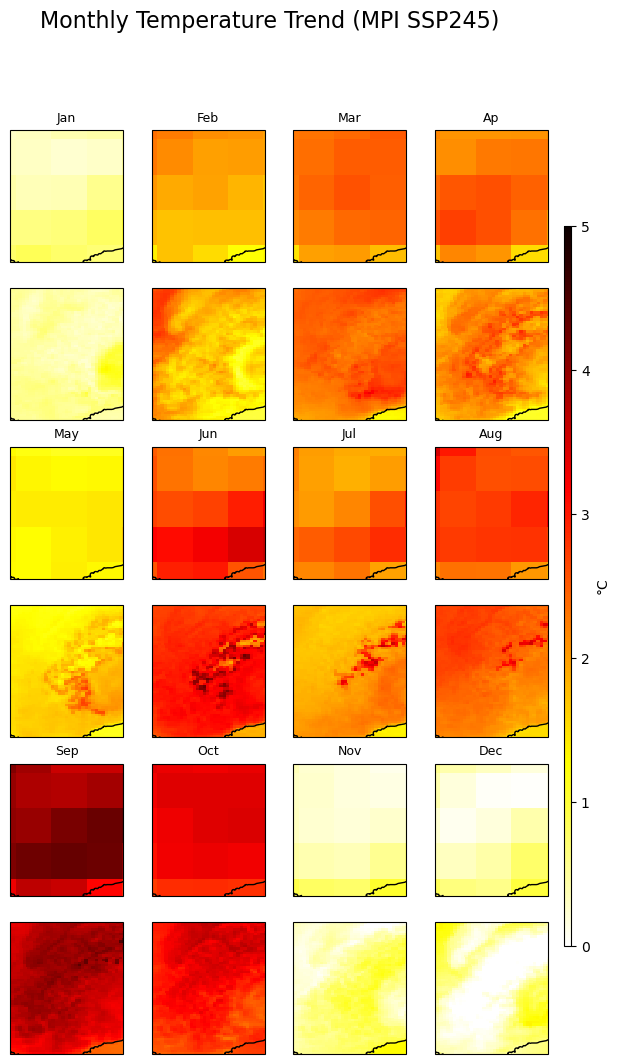

In [159]:
fig, axs = plt.subplots(6, 4, figsize=(widthPlot, 12),subplot_kw={'projection': proj},dpi=quality) 
m=0    

for i in range(0,6,2): # lines
    for j in range(4): #columns
        ax = axs[i,j]
        print(i,j,labelmonths[m])
        ax.set_title(f"{labelmonths[m]}",fontsize=9)
        # GCM
        f = ax.pcolormesh(
            longG, latiG, 100*slopeT_mG[m],
            cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
        )
        ax.add_feature(cfeature.COASTLINE)
        if (zoom):
            ax.set_xlim(5,8)
            ax.set_ylim(43.5,47)
        # MAR
        ax = axs[i+1,j]
        f = ax.pcolormesh(
            longM, latiM, 100*slopeT_mM[m],
            cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
        )
        ax.add_feature(cfeature.COASTLINE)
        if (zoom):
            ax.set_xlim(5,8)
            ax.set_ylim(43.5,47)
        m=m+1    

# ----- Colorbar -----
# Horizontal colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.01, 0.6])
fig.colorbar(f, cax=cbar_ax, orientation='vertical', label='°C')
        
    
fig.suptitle(f"Monthly {varnameLong} Trend ({GCMname} {scenario})", fontsize=16)
plt.savefig(f"{path_IMG}{GCMname}-MAR_{scenario}_{varnameShort}_Trend_month{iszoom}.png")

## 3. Compare on same grid

See https://github.com/Ian-CD/PhD/blob/master/Article_EDW/Figs_1_and_2_and_appendixB.ipynb,
Article from Ian (https://egusphere.copernicus.org/preprints/2025/egusphere-2025-6211/egusphere-2025-6211.pdf)

### 3.1 On MAR Grid

In [53]:
# import utils as u
# import xarray_regrid

# slope_TGonM = np.zeros(np.shape(slope_TM))
# print(np.shape(slope_TM))
# print(np.shape(slope_TG))
# # Plot trends for seasonal temperature for run GCM and MAR
# fig, axs = plt.subplots(nrows=2, ncols=4,figsize=(14, 3.5),
#     subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
# )
# # Color scale
# colo_map = 'hot_r'
# # Boucle principale
# for i in range(4):
#     temp_slope_TG=slope_TG[i]
#     print(temp_slope_TG)
#     slope_TGonM_xy=(temp_slope_TG.reshape(91,139))
# #slope_TGonM
# #slope_TG[i]
# #slope_TM[i]

### 3.2 On GCM Grid

In [54]:
#slope_TMonG = np.zeros(np.shape(slope_TG))

## 4 At Glacioclim location 

In [55]:
# number of years
print(yearG[-1],yearG[0])
yearG[-1]-yearG[0]+1
nby=int(yearG[-1].item()-yearG[0].item()+1)

2100.0 2015.0


In [56]:
#Define period for mean calculation
first_year_mean, last_year_mean = 2015, 2099 # 1960, 1990
temp = np.where( yearM == np.min(first_year_mean) ) # index of meantime first year in array of years
iy_i = temp[0].item()
temp = np.where( yearM == np.min(last_year_mean)  ) # index of meantime last...
iy_f = temp[0].item()
print(f"Index first, last years: {iy_i}, {iy_f}")

Index first, last years: 0, 84


In [57]:
# Calculate average on a given period

# Annual Temperature
glacioClT_yearG = np.zeros((nby,5)) # GCM
glacioClT_yearM = np.zeros((nby,5)) # MAR
# Seasonnal Temperature
glacioClT_seasG = np.zeros((nby,5,4))
glacioClT_seasM = np.zeros((nby,5,4))

# Mean Annual Temperature
glacioClTmean_yearG = np.zeros(5)
glacioClTmean_yearM = np.zeros(5)
# Mean Seasonnal Temperature
glacioClTmean_seasG = np.zeros((5,4))
glacioClTmean_seasM = np.zeros((5,4))
#glacioClTmean_seasG

In [58]:
tyeaG.shape

(86, 7, 14)

In [59]:
# Shape for 1 grid point 
tmonG[iy_i:iy_f,:,0,0].shape

(84, 12)

In [60]:
# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xlonG, ylatG = glacioClXYG[i][1], glacioClXYG[i][2]
    xlonM, ylatM = glacioClXYM[i][1], glacioClXYM[i][2]
    
    # Year Temp
    glacioClT_yearG[:,i] = tyeaG[:,ylatG,xlonG]
    glacioClT_yearM[:,i] = tyeaM[:,ylatM,xlonM]
    
    # Mean Year Temp
    glacioClTmean_yearG[i] = np.average(tyeaG[iy_i:iy_f,ylatG,xlonG])
    glacioClTmean_yearM[i] = np.average(tyeaM[iy_i:iy_f,ylatM,xlonM])
    
    # Month Temp
#    for y in range(len(yearG)):
#        glacioClT_monG[y,i] = np.average(tmonG[y,:,xG,yG])
#        glacioClT_monM[y,i] = np.average(tmonM[y,:,xM,yM])

    # Mean Month Temp
#    glacioClTmean_monG[i] = np.average(tmonG[iy_i:iy_f,:,xG,yG])
#    glacioClTmean_monM[i] = np.average(tmonM[iy_i:iy_f,:,xM,yM])

    # Seasonnal Temp
    for y in range(len(yearG)):    
        #print(tsaiG[y,:,xG,yG])
        glacioClT_seasG[y,i,:] = tsaiG[y,:,ylatG,xlonG]
        glacioClT_seasM[y,i,:] = tsaiM[y,:,ylatM,xlonM]
    
    # Mean Seasonnal Temp
    for s in range(4):
        glacioClTmean_seasG[i][s] = np.average(tsaiG[iy_i:iy_f,s,ylatG,xlonG]) 
        glacioClTmean_seasM[i][s] = np.average(tsaiM[iy_i:iy_f,s,ylatM,xlonM])

In [61]:
#print(glacioClT_yearG)

In [62]:
print("Check the size of data Array:")
print(tyeaG.shape)
print(tmonG.shape)
print(tsaiG.shape)
print(glacioClTmean_yearM.shape)
print(glacioClTmean_seasM.shape)
print(glacioClT_seasM.shape)

Check the size of data Array:
(86, 7, 14)
(86, 12, 7, 14)
(86, 4, 7, 14)
(5,)
(5, 4)
(86, 5, 4)


In [63]:
# Plot 1 : massif du Mont Blanc 4 saisons
print("glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:")
print(glacioClT_yearG.shape)
print(glacioClTmean_yearG.shape)

glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:
(86, 5)
(5,)


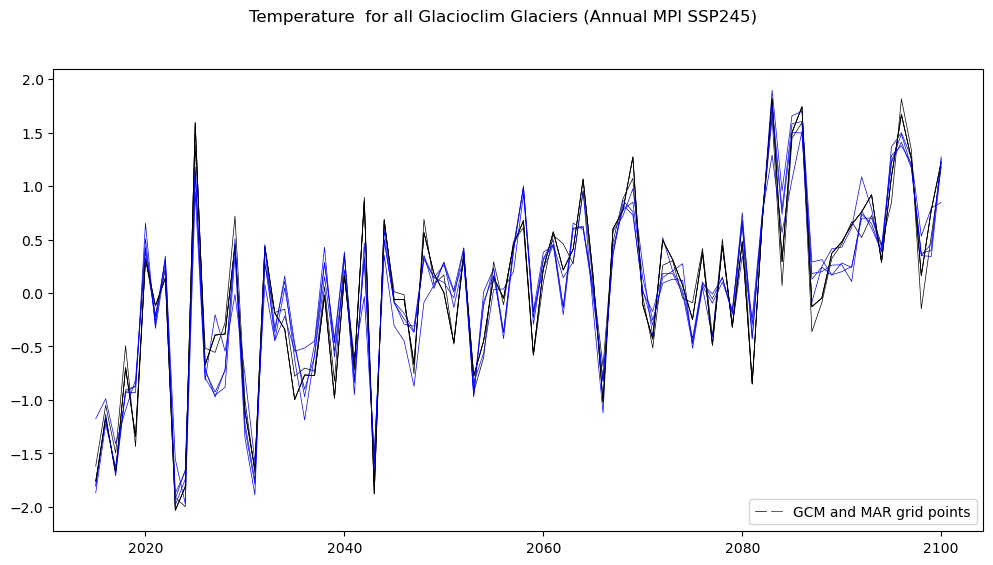

In [64]:
#Plot temperatures mensuelles pour 4 glacier
from matplotlib.legend_handler import HandlerTuple

fig, ax = plt.subplots(1, figsize=(12, 6))
for i in range(4):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
 #   xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2] # error
 #   xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2] # error
    xlonG, ylatG = glacioClXYG[ii][1], glacioClXYG[ii][2] # ok but useless here
    xlonM, ylatM = glacioClXYM[ii][1], glacioClXYM[ii][2] # ok but useless here

    
    line1, = ax.plot(yearG,glacioClT_yearG[:,ii]-glacioClTmean_yearG[ii],'k',lw=0.5)     # T Ann
    line2, = ax.plot(yearG,glacioClT_yearM[:,ii]-glacioClTmean_yearM[ii],'b',lw=0.5)        # T Ann

# Creating custom legend handles
handles = [(line1, line2)]
labels = ['GCM and MAR grid points']
# Adding the custom legend
ax.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)},loc='lower right')    

fig.suptitle(f"{varnameLong}  for all Glacioclim Glaciers (Annual {GCMname} {scenario})", fontsize=12)
plt.savefig(f"{varnameShort} _all_Glacioclim_Glaciers_Annual_{GCMname}_{scenario}.png")

#fig.suptitle(f"Temperature for all Glacioclim Glaciers (Annual {GCMname} {scenario})", fontsize=12)
#plt.savefig(f"Temperature_all_Glacioclim_Glaciers_Annual_{GCMname}_{scenario}.png")

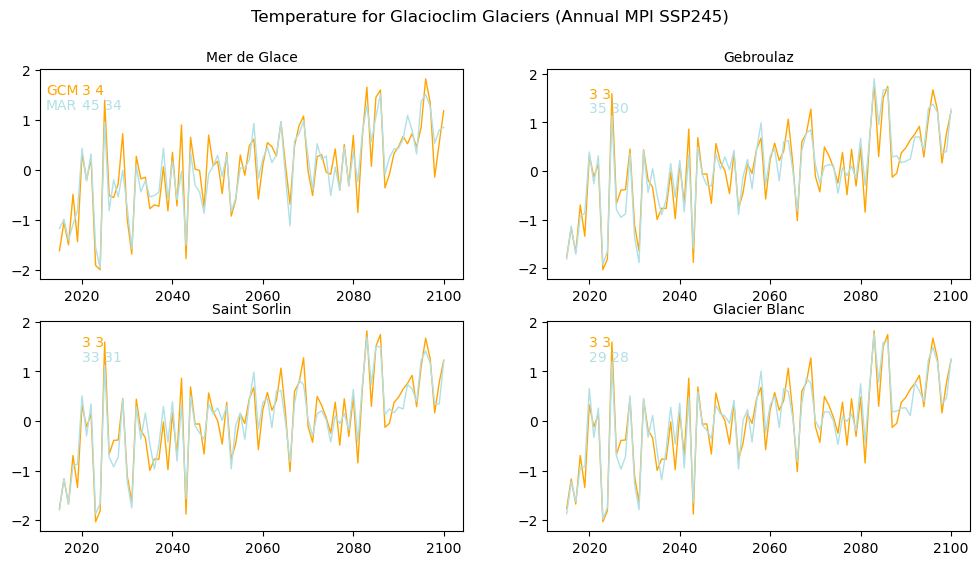

In [65]:
# Computing trends for all Glacioclim glacier (Temperature linear regression)
slope_T_loc=np.full(5,np.nan)
pvalue_T_loc=np.full(5,np.nan)
intercept_T_loc=np.full(5,np.nan)

#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()



for i, ax in enumerate(axs):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    #xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    #xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]
    xlonG, ylatG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    xlonM, ylatM = glacioClXYM[ii][1], glacioClXYM[ii][2]
    
    ax.plot(yearG,glacioClT_yearG[:,ii]-glacioClTmean_yearG[ii],color='orange',lw=1)      # T Ann
    ax.plot(yearG,glacioClT_yearM[:,ii]-glacioClTmean_yearM[ii],color='powderblue',lw=1)  # T Ann
    ax.text(2020,1.5,f'{xlonG} {ylatG}',color='orange')
    ax.text(2020,1.2,f'{xlonM} {ylatM}',color='powderblue')    
    #ax.plot(yearG,glacioClT_yearM[:,ii])        # T Ann

    #print(glacioClTmean_yearG[ii])
    #print(np.mean(tannG[:,1,xG,yG]))
    # Computing trends

    
    ax.set_title(glaName,fontsize=10)

axs[0].text(2012,1.5,'GCM',color='orange')
axs[0].text(2012,1.2,'MAR',color='powderblue')

fig.suptitle(f'{varnameLong} for Glacioclim Glaciers (Annual {GCMname} {scenario})', fontsize=12)
plt.savefig(f'{varnameShort}_Glacioclim_Glaciers_Annual_{GCMname}_{scenario}.png')

### Seasonnal 

In [66]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]

0 DJF
1 MAM
2 JJA
3 SON


Text(0.5, 0.98, 'Temperature  for all Glacioclim Glaciers (MPI SSP245)')

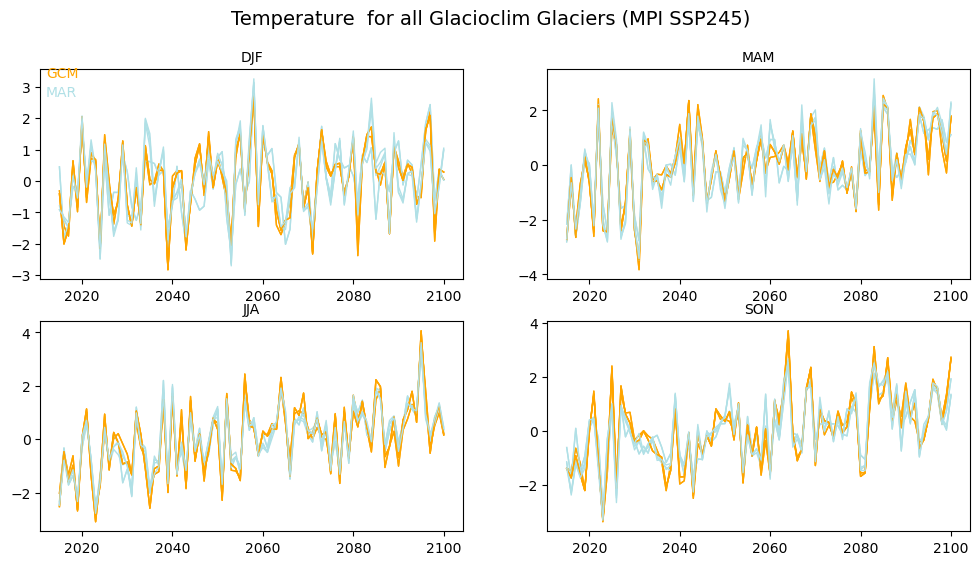

In [67]:
#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs.ravel()

s = 0 # seasons

for i in range(len(axs)):
    for j in range(len(axs[0])):
        label = labelseasons[s]
        print(s, label)
        ax = axs[i][j]
        ax.set_title(labelseasons[s], fontsize=10)
        for ii in range(len(glacioClXYG)):
            ax.plot(yearG,glacioClT_seasG[:,ii,s]-glacioClTmean_seasG[ii,s],'orange',lw=1) 
            ax.plot(yearG,glacioClT_seasM[:,ii,s]-glacioClTmean_seasM[ii,s],color='powderblue',lw=1)
            #ax.plot(yearG,glacioClT_seasG[:,ii,s]-glacioClTmean_seasG[ii,s],'k',lw=0.5) 
            #ax.plot(yearG,glacioClT_seasM[:,ii,s]-glacioClTmean_seasM[ii,s],'b',lw=0.5)
        s=s+1

axs[0,0].text(2012,3.3,'GCM',color='orange')
axs[0,0].text(2012,2.7,'MAR',color='powderblue')
fig.suptitle(f"{varnameLong}  for all Glacioclim Glaciers ({GCMname} {scenario})", fontsize=14)

Text(2012, 1.2, 'MAR')

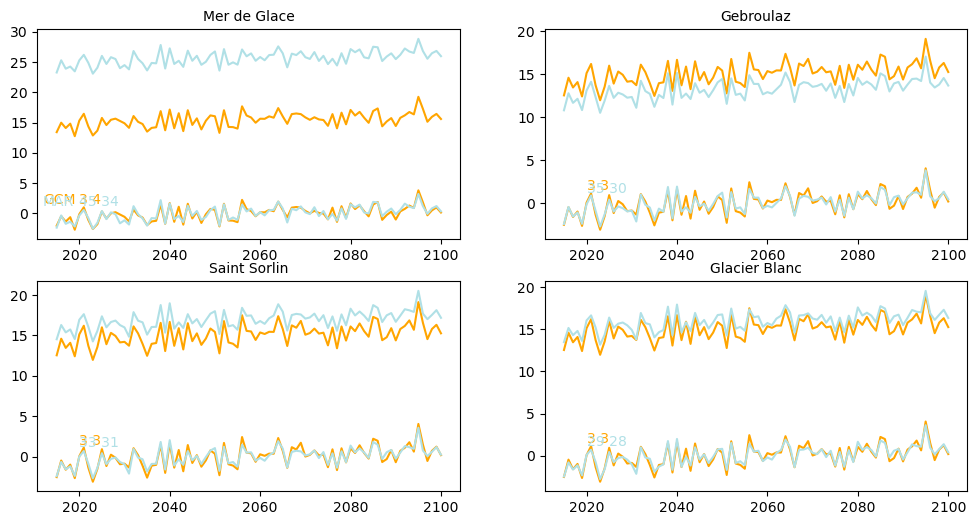

In [68]:
# Computing trends for all Glacioclim glacier (Temperature linear regression)
slope_T_loc=np.full(5,np.nan)
pvalue_T_loc=np.full(5,np.nan)
intercept_T_loc=np.full(5,np.nan)

#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()

s = 2 # summer

for i, ax in enumerate(axs):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    #xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    #xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]
    xlonG, ylatG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    xlonM, ylatM = glacioClXYM[ii][1], glacioClXYM[ii][2]

    ax.plot(yearG,glacioClT_seasG[:,ii,s],color='orange')      # T Seas
    ax.plot(yearG,glacioClT_seasM[:,ii,s],color='powderblue')     
    ax.plot(yearG,glacioClT_seasG[:,ii,s]-glacioClTmean_seasG[ii,s],color='orange')      # T Seas
    ax.plot(yearG,glacioClT_seasM[:,ii,s]-glacioClTmean_seasM[ii,s],color='powderblue')        # T Seas
    ax.text(2020,1.5,f'{xlonG} {ylatG}',color='orange')
    ax.text(2020,1.2,f'{xlonM} {ylatM}',color='powderblue')    
    #ax.plot(yearG,glacioClT_yearM[:,ii])        # T Ann

    #print(glacioClTmean_yearG[ii])
    #print(np.mean(tannG[:,1,xG,yG]))
    # Computing trends

    
    ax.set_title(glaName,fontsize=10)

axs[0].text(2012,1.5,'GCM',color='orange')
axs[0].text(2012,1.2,'MAR',color='powderblue')

## 5 For a Massif

### 5.1 Create mask for the massif (Mont Blanc)

In [69]:
### ### Number of the glacioclim glacier concerned (ie MdG)
ig=1 #MdG
### ###

In [70]:
### ### Create a mask for the massif
### 1. Create the polygon
### 2. Create the 2D mask that will contain(lon,lat) at each point mask[i,j] 
### 3. Create a 2D table that will contain the (i,j) at each point table[i,j]
### 4. Fill the mask and the table
### 5. Does the points (lon,lat) are inside the poygon
###   a   Reshape Massif 2D -> 1D 
###   b   Belonging test : True if Inside poygon, False elsewhere 
###   c   Reshape 1D -> 2D
### 6. Update 2D mask and 2D table : values only for massif

# 1. Création du polygone
path = Path(patches[i_ployg].get_xy())
print(longM.shape)
# 2. 3.
Massif2D = np.zeros((91,139,2))
ij_table = np.zeros((91,139,2))
# 4.
for i in range(len(longM[:,0])):
    for j in range(len(longM[0,:])):
        #print(Massif_MB[i,j],[longM[i,j].item(),latiM[i,j].item()])
        Massif2D[i,j,:]=[longM[i,j].item(),latiM[i,j].item()]
        ij_table[i,j,:]=[i,j]

# 5. Test d'appartenance
# 5.a
print("Massif2D.shape",Massif2D.shape)
Massif1D = Massif2D.reshape(91*139,2)
print("Reshaped: Massif1D.shape",Massif1D.shape)
# 5.b
mask1D = path.contains_points(Massif1D)
# 5.c 
mask2D = mask1D.reshape(91,139)
print('1D mask.shape',mask1D.shape)
print('2D mask.shape',mask2D.shape)
print(mask2D)

# 6. 
inside_points_lola = Massif2D[mask2D] # lon lat
inside_points_ij = ij_table[mask2D]   # i j 

print('inside_points_ij:\n',inside_points_ij)
#for lola in inside_points_lola :
print(inside_points_lola)
    
print(f'Shape is {inside_points_ij.shape}')
print(f'There is {inside_points_ij.shape[0]} points in the massif')

(91, 139)
Massif2D.shape (91, 139, 2)
Reshaped: Massif1D.shape (12649, 2)
1D mask.shape (12649,)
2D mask.shape (91, 139)
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
inside_points_ij:
 [[43. 31.]
 [43. 32.]
 [44. 31.]
 [44. 32.]
 [44. 33.]
 [44. 34.]
 [45. 32.]
 [45. 33.]
 [45. 34.]
 [45. 35.]
 [46. 33.]
 [46. 34.]
 [46. 35.]
 [47. 34.]]
[[ 6.6583395  45.79473877]
 [ 6.74861479 45.7951355 ]
 [ 6.65773249 45.8576889 ]
 [ 6.74810982 45.85807037]
 [ 6.83848524 45.85838699]
 [ 6.92886305 45.85863495]
 [ 6.74760485 45.92100143]
 [ 6.83808184 45.92132568]
 [ 6.92855883 45.92157364]
 [ 7.0190382  45.92175674]
 [ 6.83767366 45.984272  ]
 [ 6.92825317 45.98452377]
 [ 7.01883459 45.98469925]
 [ 6.92794847 46.04746246]]
Shape is (14, 2)
There is 14 points in the massif


### 5.2 Get MAR and GCM Temp and trend for the points of the massif

### MAR Temp

In [71]:
# Initialize : (year,season,points)
# Annual Temperature
MBT_yearG = np.zeros(nby)
MBT_yearM = np.zeros((nby,len(inside_points_ij)))
# Seasonnal Temperature
MBT_seasG = np.zeros((nby,4))
MBT_seasM = np.zeros((nby,len(labelseasons),len(inside_points_ij)))
# Month Temperature
MBT_monG = np.zeros((nby,12))
MBT_monM = np.zeros((nby,12,len(inside_points_ij)))

# Mean Annual Temperature
MBTmean_yearG = 0.
MBTmean_yearM = np.zeros(len(inside_points_ij))
# Mean Seasonnal Temperature
MBTmean_seasG = np.zeros(len(labelseasons))
MBTmean_seasM = np.zeros((len(labelseasons),len(inside_points_ij)))
# Mean Month Temperature
MBTmean_monG = np.zeros(12)
MBTmean_monM = np.zeros((12,len(inside_points_ij)))

In [72]:
### Get values:

# Temp and Calculate mean temp for MAR points in the massif

for i in range(len(inside_points_ij)):
    # Data MAR 2 matrix coordinates (LON,LAT)
    #print(inside_points1)
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # Mean Annual Temp
    MBTmean_yearM[i] = np.average(tyeaM[iy_i:iy_f,yM,xM])
    
    # Annual Temp
    MBT_yearM[:,i] = tyeaM[:,yM,xM]
        
    # Season,nal Temp
    for s in range(4): 
        MBTmean_seasM[s][i] = np.average(tsaiM[iy_i:iy_f,s,yM,xM])

    # monthly Temp
    for m in range(12): 
        MBTmean_monM[s][i] = np.average(tmonM[iy_i:iy_f,m,yM,xM])

### MAR Temp Trend

In [73]:
### Initialize :
# Mean Annual Temperature Trend 
MBTtrend_yearM = np.zeros(len(inside_points_ij))
# Mean Seasonnal 
MBTtrend_seasM = np.zeros((len(labelseasons),len(inside_points_ij)))
# Mean month 
MBTtrend_monM = np.zeros((12,len(inside_points_ij)))

In [149]:

### Get values:
for i in range(len(inside_points_ij)):
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # Fill Ann Temp trend for each point of the massif
    MBTtrend_yearM[i] = slopeT_yM[xM,yM]
    # Fill Season Temp trend
    for s in range(len(labelseasons)):    
        MBTtrend_seasM[s,i] = slopeT_sM[s,xM,yM]
    for m in range(12):    
        MBTtrend_monM[m,i] = slopeT_mM[m,xM,yM]    
print('MBTtrend_yearM',MBTtrend_yearM.shape,'\n',MBTtrend_yearM) ###### MBT_trendM

MBTtrend_yearM (14,) 
 [0.0204722  0.0204743  0.02027845 0.0200349  0.01989898 0.02031321
 0.01942294 0.02060235 0.02058479 0.02041758 0.02014909 0.02009076
 0.01981795 0.0196956 ]


### 5.3 GCM Temp & Trend

In [154]:
### Get values for GCM
xlonG, ylatG = glacioClXYG[ig][1], glacioClXYG[ig][2] # ig defined above
print(ig, xlonG, ylatG)
print(f'GCM : {glacioClXYG[ig][0]} ij are {xlonG},{ylatG}')

# Annual Temperature trend GCM
MBTtrend_yearG = slopeT_yG[ylatG,xlonG]
print('MBTtrend_yearG:',MBTtrend_yearG)

# Seasonnal Temperature trend GCM
MBTtrend_seasG = np.zeros(len(labelseasons))
for s in range(len(labelseasons)):
        MBTtrend_seasG[s] = slopeT_sG[s,ylatG,xlonG]
print('MBTtrend_seasG:',MBTtrend_seasG)

# Monthly Temperature trend GCM
MBTtrend_monG = np.zeros(12)
for m in range(12):
        MBTtrend_monG[m] = slopeT_mG[m,ylatG,xlonG]
print('MBTtrend_monG:',MBTtrend_monG)

1 3 4
GCM : Mer de Glace ij are 3,4
MBTtrend_yearG: 0.018569280772935928
MBTtrend_seasG: [0.00751605 0.02019725 0.02204966 0.02451491]
MBTtrend_monG: [0.00236779 0.01978157 0.02491039 0.02271657 0.01296476 0.02169576
 0.0186583  0.02579502 0.0374947  0.03415954 0.00189059 0.00039874]


### 5.4 Topo

In [76]:
# Topo MAR (surface elevation)
wp_Topo_MAR = np.load(path_DIR+'numpyData/topo_MAR_SurfaceH'+'.npz')
print(wp_Topo_MAR)
topoMAR=wp_Topo_MAR['SH']

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/topo_MAR_SurfaceH.npz' with keys: SH


In [77]:
# Altitude
topoMARMassif = np.zeros((len(inside_points_ij)))
for i in range(len(inside_points_ij)):
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # Fill Altitude
    topoMARMassif[i] = topoMAR[xM,yM] 

In [78]:
# Topo GCM (surface elevation)
wp_Topo_GCM = np.load(path_DIR+'numpyData/topo_GCM_MPI_SurfaceH'+'.npz')
print(wp_Topo_GCM)
topoGCM=wp_Topo_GCM['SH']

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/topo_GCM_MPI_SurfaceH.npz' with keys: SH


In [79]:
from copy import copy

colo_scale='tab20b'#'terrain'# 'gist_earth'
vmin_scale=500
vmax_scale=3000

1057.1655


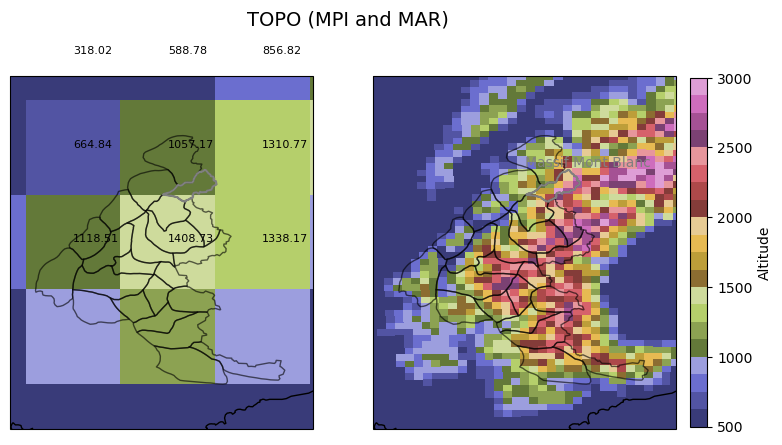

In [80]:
# Plot TOPO for GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(9, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)

# ----- GCM -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
cb = ax.pcolormesh(longG, latiG, topoGCM, # 100*slope_T_hist[i] ????????
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
#ax.text(5.7, 46.8, f"{np.mean(slopeT_yG[i]):.3f}°C/centuries",
#        ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, topoMAR,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
#ax.text(5.7, 46.8, f"{np.mean(slopeT_yM[i]):.3f}°C/centuries",
#            ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("Altitude")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
    
    axs[i].set_xlim(5,8)
    axs[i].set_ylim(43.5,47)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0].add_collection(collection2)
axs[1].add_collection(collection3)

############# write values around MdG ####
print(topoGCM[glacioClXYG[1][2],glacioClXYG[1][1]])
for ii in np.arange(-1,2):
    for jj in np.arange(-1,2):
        ilat, jlon = glacioClXYG[1][1]+ii, glacioClXYG[1][2]+jj 
        #print(longG[glacioClXYG[1][1]+ii], latiG[glacioClXYG[1][2]+jj], f'{100*slopeT_sG[i,glacioClXYG[1][1]+ii,glacioClXYG[1][2]+jj]}')
        axs[0].text(longG[ilat], latiG[jlon], f'{topoGCM[jlon,ilat]:.2f}',fontsize=8)

# Plot Mont Blanc in grey
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].text(6.5,46.1,"Massif Mont Blanc",color='gray')

fig.suptitle(f"TOPO ({GCMname} and MAR)", fontsize=14)
plt.savefig(f"{path_IMG}{GCMname}-MAR_TOPO_zoom.png")

In [81]:
print(f'GCM TOP0 {glacioClXYG[1][0]}({glacioClXYG[1][1]},{glacioClXYG[1][2]}) and neigbhourg:')
iglaa,jglaa = glacioClXYG[1][1],glacioClXYG[1][2]
#print(iglaa,jglaa)
    #glacioClXYG[i][1]  
for i in np.arange(-1,2):
    print(iglaa+i,jglaa+jrange)
    
for i in np.arange(-1,2):
    print(topoGCM[jglaa+jrange,iglaa+i]) 

GCM TOP0 Mer de Glace(3,4) and neigbhourg:
2 [3 4 5]
3 [3 4 5]
4 [3 4 5]
[1118.5148   664.839    318.01556]
[1408.7299 1057.1655  588.7836]
[1338.1746 1310.7695  856.8151]


In [82]:
inside_points_lola[:,0]

array([6.6583395 , 6.74861479, 6.65773249, 6.74810982, 6.83848524,
       6.92886305, 6.74760485, 6.83808184, 6.92855883, 7.0190382 ,
       6.83767366, 6.92825317, 7.01883459, 6.92794847])

In [83]:
topoMARMassif

array([1862.23474121, 2143.88598633, 1630.87927246, 1685.8560791 ,
       2951.0300293 , 2657.9543457 , 1223.03649902, 1844.0793457 ,
       2449.73510742, 2748.94238281, 2001.69921875, 1951.18664551,
       2852.06542969, 1950.74597168])

In [84]:
longM[1,1]

np.float32(4.0959926)

Argentiere
Mer de Glace


/var/folders/hx/9_6qztjn4pj086nky0f3801c0000gr/T/ipykernel_21591/314438295.py:32: UserWarning: Adding colorbar to a different Figure <Figure size 900x500 with 3 Axes> than <Figure size 800x500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cb, ax=axs, orientation="vertical",


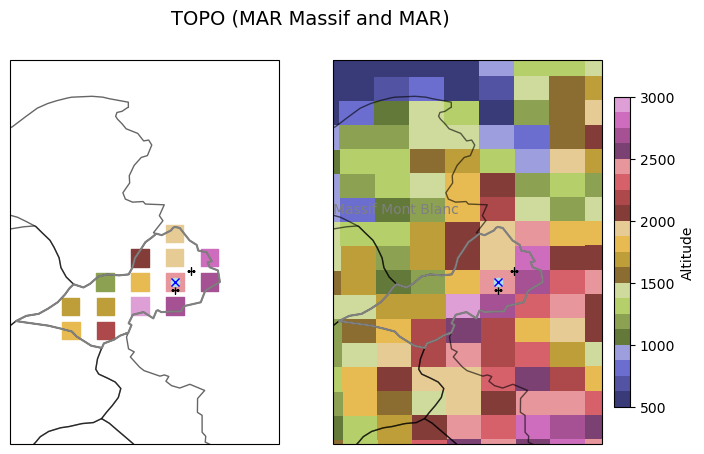

In [85]:
# ZOOM
lonZoomMin, lonZoomMax = 5,8
latZoomMin, latZoomMax = 43.5,47
markersize=15
# ZOOM
lonZoomMin, lonZoomMax = 6.5,7.2
latZoomMin, latZoomMax = 45.5,46.5
markersize=160

# Plot TOPO for GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(8, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)

# ----- MAR MASSIF -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
#cb = ax.pcolormesh(longG, latiG, topoMARMassif, 
ax.scatter(inside_points_lola[:,0],inside_points_lola[:,1], c=topoMARMassif, #x,y,z
                   marker='s',s=markersize,
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, topoMAR,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("Altitude")

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
    
    axs[i].set_xlim(lonZoomMin, lonZoomMax)
    axs[i].set_ylim(latZoomMin, latZoomMax)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0].add_collection(collection2)
axs[1].add_collection(collection3)

# Plot Mont Blanc in grey
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].text(6.5,46.1,"Massif Mont Blanc",color='gray')

# Plot Arg
print(glacioClim[0][0])
axs[0].plot(glacioClim[0][1],glacioClim[0][2],'+',color='k') # lon lat
axs[1].plot(glacioClim[0][1],glacioClim[0][2],'+',color='k')
#
i_inMAR,j_inMAR=glacioClXYM[0][1],glacioClXYM[0][2] 
axs[0].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'o',color='powderblue') # MAR GRID
axs[1].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'o',color='powderblue')
# Plot MdG
print(glacioClim[1][0])
axs[0].plot(glacioClim[1][1],glacioClim[1][2],'+',color='k')
axs[1].plot(glacioClim[1][1],glacioClim[1][2],'+',color='k')
#
i_inMAR,j_inMAR=glacioClXYM[1][1],glacioClXYM[1][2] 
axs[0].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'x',color='blue') # MAR GRID
axs[1].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'x',color='blue')


fig.suptitle(f"TOPO (MAR Massif and MAR)", fontsize=14)
plt.savefig(f"{path_IMG}MARMassif_TOPO_zoom.png")

Mer de Glace 45 34 2449.735


Text(0.5, 0.98, 'TOPO MAR Massif (identify points)')

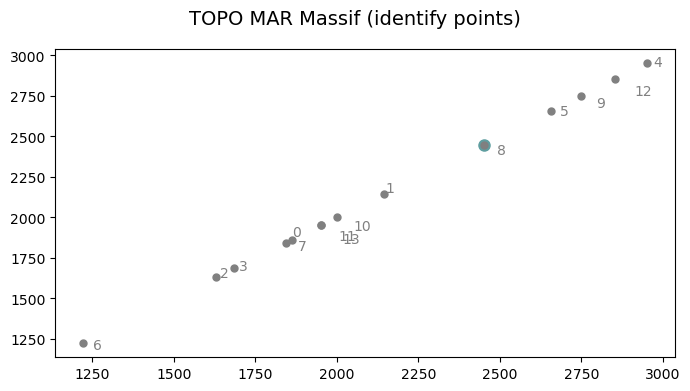

In [86]:
fig, ax = plt.subplots(1, figsize=(8, 4))


    
# Arg & MdG
nameM, xM, yM = glacioClXYM[ig][0], glacioClXYM[ig][1],glacioClXYM[ig][2]
print(nameM, xM, yM,topoMAR[xM, yM])
ax.plot(topoMAR[xM, yM],topoMAR[xM, yM],'o',ms=8,color='cadetblue',label=nameM)

for pt in range(len(inside_points_ij)): 
    ax.plot(topoMARMassif[pt],topoMARMassif[pt],'o',color='grey',ms=5) 
    ax.text(topoMARMassif[pt]+pt*5,topoMARMassif[pt]-10*(pt-2),f'{pt}',color='grey') 

fig.suptitle(f"TOPO MAR Massif (identify points)", fontsize=14)

### 5.4 Plot Temperature for all points of MontBlanc Massif

In [87]:
pt=0
print(MBT_yearM[:,pt])
print(MBTmean_yearM[pt])

[12.60858536 12.72425842 12.25728607 12.61067677 12.9336729  14.11394215
 13.48932171 14.09764004 12.19239426 11.79718018 14.77701569 12.94155788
 13.50035572 13.06377697 13.65897655 12.91047668 12.21169281 13.88919449
 13.25964451 13.4113512  13.03998089 13.17300129 13.17292786 14.07106495
 12.9893074  13.76557446 13.08417988 13.74819088 12.20835781 14.14792538
 13.39403629 13.26237011 12.89640713 13.72883987 13.86065197 14.0671072
 13.57366657 14.10049438 12.81258297 13.22557163 13.72928905 13.7746582
 13.98650742 14.69443893 13.36731243 13.80646133 14.22432995 13.7688055
 14.08414555 14.71486282 13.66392994 12.58272648 14.32400227 14.42406464
 14.84661102 13.9719286  13.3702879  14.15637684 13.87336254 13.96607685
 13.15394306 13.74795818 13.33681107 14.18255997 13.39535141 14.1241951
 13.42427349 14.35363293 15.11383152 14.30352879 14.76706982 15.29346085
 13.63400745 13.99172306 14.2409296  14.13568592 14.22911358 14.7381134
 14.51941395 13.9669342  15.10468578 15.3286047  15.0389

In [88]:
# Same figure with all point in a massif
#For 1 glacier : Mont Blanc
ii=1 # Mer de Glace
print ("glacier: ",glacioClXYG[ii][0])
glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]

glacier:  Mer de Glace


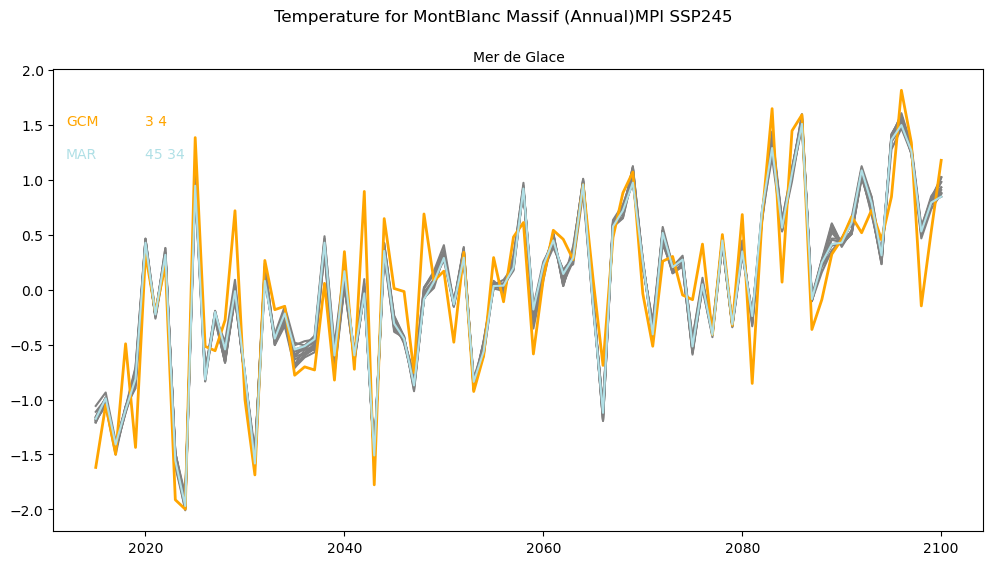

In [89]:
#Plot temperatures mensuelles pour 4 glacier
fig, ax = plt.subplots(1, figsize=(12, 6))
#axs = axs.ravel()

# Loop on all the point of the massif
for pt in range(len(inside_points_ij)): 
        ax.plot(yearG,MBT_yearM[:,pt]-MBTmean_yearM[pt],color='grey') # -MBTmean_yearM[pt]
   
ax.plot(yearG,glacioClT_yearG[:,ii]-glacioClTmean_yearG[ii],color='orange',lw=2)      # T Ann -glacioClTmean_yearG[ii]
ax.plot(yearG,glacioClT_yearM[:,ii]-glacioClTmean_yearM[ii],color='powderblue')        # T Ann -glacioClTmean_yearM[ii]


ax.text(2020,1.5,f'{xG} {yG}',color='orange')
ax.text(2020,1.2,f'{xM} {yM}',color='powderblue')    
    #ax.plot(yearG,glacioClT_yearM[:,ii])        # T Ann

    #print(glacioClTmean_yearG[ii])
    #print(np.mean(tannG[:,1,xG,yG]))
    # Computing trends

    
ax.set_title(glaName,fontsize=10)

ax.text(2012,1.5,'GCM',color='orange')
ax.text(2012,1.2,'MAR',color='powderblue')

fig.suptitle(f'{varnameLong} for MontBlanc Massif (Annual){GCMname} {scenario}', fontsize=12)
fig.savefig(f'{varnameLong}forMontBlancMassif_Annual__{GCMname}_{scenario}.png')

### 5.4.1 Annual Plot (MontBlanc Massif)

In [90]:

print('MBT_trendM',MBTtrend_yearM.shape,'\n',MBTtrend_yearM)

MBT_trendM (14,) 
 [0.0204722  0.0204743  0.02027845 0.0200349  0.01989898 0.02031321
 0.01942294 0.02060235 0.02058479 0.02041758 0.02014909 0.02009076
 0.01981795 0.0196956 ]


glacier:  Mer de Glace
Mer de Glace 45 34 218.12999
[0.0204722  0.0204743  0.02027845 0.0200349  0.01989898 0.02031321
 0.01942294 0.02060235 0.02058479 0.02041758 0.02014909 0.02009076
 0.01981795 0.0196956 ]


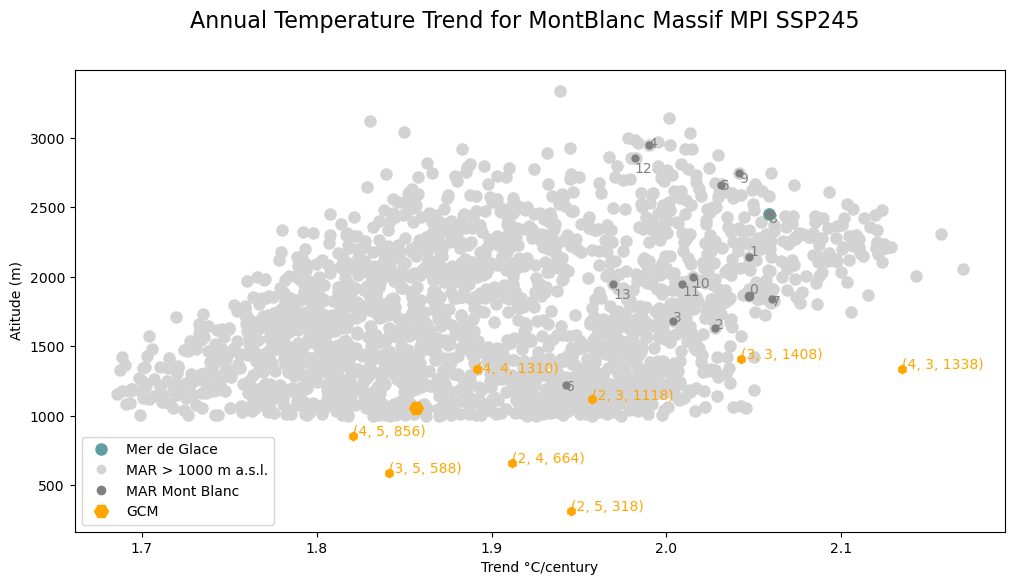

In [91]:
# Same figure with all point in a massif
#For 1 glacier : Mont Blanc
print ("glacier: ",glacioClXYG[ig][0])

#Plot temperatures mensuelles pour 4 glacier
fig, ax = plt.subplots(1, figsize=(12, 6))
#axs = axs.ravel()

### MAR

# French Alps
for i in range(20,80):
    for j in range(10,110):
        if topoMAR[i, j] >=1000:
            ax.plot(100*slopeT_yM[i,j],topoMAR[i, j],'o',ms=8,color='lightgrey')
# Arg & MdG
nameM, xM, yM = glacioClXYM[ig][0], glacioClXYM[ig][1],glacioClXYM[ig][2]
print(nameM, xM, yM,topoMAR[yM, xM])
ax.plot(100*slopeT_yM[xM,yM],topoMAR[xM, yM],'o',ms=8,color='cadetblue',label=nameM) # !!!!!!!!!!!!!!!!!
# !!!!!!!!!!!!! slopeT_yM[yM,xM] AND topoMAR[xM, yM]

print(MBTtrend_yearM)

#Mont Blanc
ax.plot(100*MBTtrend_yearM[0],topoMARMassif[0],'o',color='lightgrey',label='MAR > 1000 m a.s.l.')
ax.plot(100*MBTtrend_yearM[0],topoMARMassif[0],'o',color='grey',label='MAR Mont Blanc')
# Loop on all the point of the massif
for pt in range(len(inside_points_ij)): 
    ax.plot(100*MBTtrend_yearM[pt],topoMARMassif[pt],'o',color='grey',ms=5) # -MBTmean_yearM[pt]
    ax.text(100*MBTtrend_yearM[pt],topoMARMassif[pt]-10*(pt-2),f'{pt}',color='grey') 
    
### GCM  
ax.plot(100*MBTtrend_yearG, topoGCM[ylatG,xlonG],'H',color='orange', ms=10,label='GCM')
#neighbor points
ax.plot(100*slopeT_yG[ylatG-1,xlonG-1], topoGCM[ylatG-1,xlonG-1],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG-1,xlonG],   topoGCM[ylatG-1,xlonG],  color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG-1,xlonG+1], topoGCM[ylatG-1,xlonG+1],color='orange',marker='h')

ax.plot(100*slopeT_yG[ylatG,xlonG-1], topoGCM[ylatG,xlonG-1],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG,xlonG+1], topoGCM[ylatG-1,xlonG+1],color='orange',marker='h')

ax.plot(100*slopeT_yG[ylatG+1,xlonG-1], topoGCM[ylatG+1,xlonG-1],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG+1,xlonG],   topoGCM[ylatG+1,xlonG],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG+1,xlonG+1], topoGCM[ylatG+1,xlonG+1],color='orange',marker='h')

if (True):
    ax.text(100*slopeT_yG[ylatG-1,xlonG-1], topoGCM[ylatG-1,xlonG-1],f'{xlonG-1,ylatG-1,int(topoGCM[ylatG-1,xlonG-1])}',color='orange')
    ax.text(100*slopeT_yG[ylatG-1,xlonG],   topoGCM[ylatG-1,xlonG],  f'{xlonG,ylatG-1,int(topoGCM[ylatG-1,xlonG])}',color='orange')
    ax.text(100*slopeT_yG[ylatG-1,xlonG+1], topoGCM[ylatG-1,xlonG+1],f'{xlonG+1,ylatG-1,int(topoGCM[ylatG-1,xlonG+1])}',color='orange')  

    ax.text(100*slopeT_yG[ylatG,xlonG-1], topoGCM[ylatG,xlonG-1],f'{xlonG-1,ylatG,int(topoGCM[ylatG,xlonG-1])}',color='orange')
    ax.text(100*slopeT_yG[ylatG,xlonG+1], topoGCM[ylatG,xlonG+1],f'{xlonG+1,ylatG,int(topoGCM[ylatG,xlonG+1])}',color='orange')  


    ax.text(100*slopeT_yG[ylatG+1,xlonG-1], topoGCM[ylatG+1,xlonG-1],f'{xlonG-1,ylatG+1,int(topoGCM[ylatG+1,xlonG-1])}',color='orange')
    ax.text(100*slopeT_yG[ylatG+1,xlonG],   topoGCM[ylatG+1,xlonG],  f'{xlonG,ylatG+1,int(topoGCM[ylatG+1,xlonG])}',color='orange')
    ax.text(100*slopeT_yG[ylatG+1,xlonG+1], topoGCM[ylatG+1,xlonG+1],f'{xlonG+1,ylatG+1,int(topoGCM[ylatG+1,xlonG+1])}',color='orange')  
    
ax.set_xlabel('Trend °C/century')
ax.set_ylabel('Atitude (m)')
ax.legend(loc='lower left')

fig.suptitle(f"Annual {varnameLong} Trend for MontBlanc Massif {GCMname} {scenario}", fontsize=16)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_MontBlancMassif_Trend_annual.png")

### 5.4.2 Seasonnal Plot (MontBlanc Massif)

In [92]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]

In [93]:
topoGCM[xG,yG]

np.float32(1338.1746)

In [94]:
print(MBTtrend_seasG, topoGCM[xG,yG])

[0.00751605 0.02019725 0.02204966 0.02451491] 1338.1746


0 DJF
Mer de Glace 45 34 2449.735
1 MAM
Mer de Glace 45 34 2449.735
2 JJA
Mer de Glace 45 34 2449.735
3 SON
Mer de Glace 45 34 2449.735


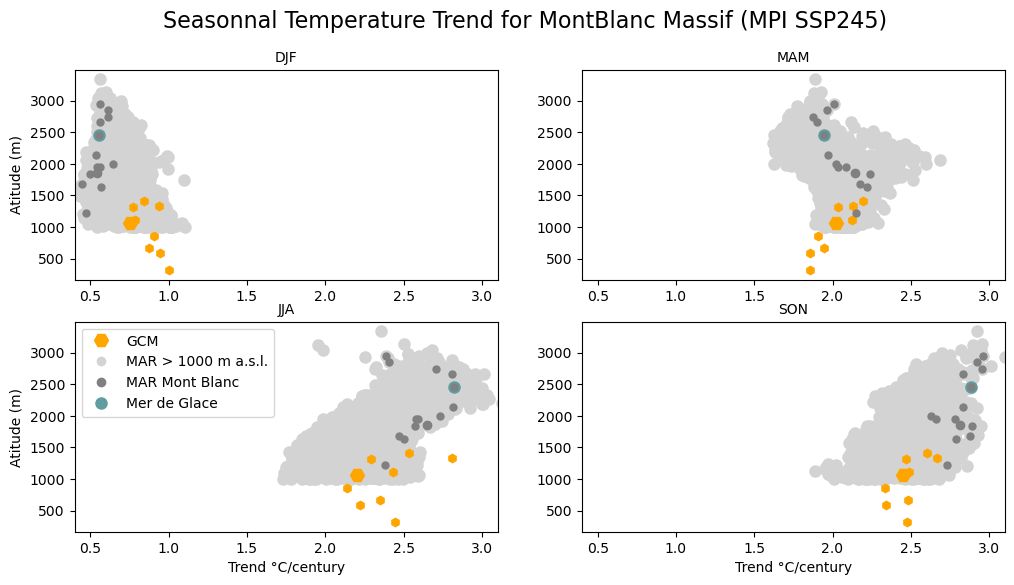

In [95]:
# Figure trend for all point in a massif
#For 1 glacier : Mont Blanc

fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs.ravel()

s = 0 # seasons

for i in range(len(axs)):
    for j in range(len(axs[0])):
        label = labelseasons[s]
        print(s, label)
        ax = axs[i][j]
        ax.set_title(labelseasons[s], fontsize=10)
        
        # MAR
        # French Alps
        for ii in range(20,80):
            for jj in range(10,110):
                if topoMAR[ii, jj] >=1000:
                    ax.plot(100*slopeT_sM[s,ii,jj],topoMAR[ii,jj],'o',ms=8,color='lightgrey')

        # GCM  
        ax.plot(100*MBTtrend_seasG[s], topoGCM[ylatG,xlonG],'H',color='orange', ms=10,label='GCM')  # !!!!!!! # !!!!!!!
        #neighbor points
        ax.plot(100*slopeT_sG[s,ylatG-1,xlonG-1], topoGCM[ylatG-1,xlonG-1],color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG-1,xlonG],   topoGCM[ylatG-1,xlonG],  color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG-1,xlonG+1], topoGCM[ylatG-1,xlonG+1],color='orange',marker='h')

        ax.plot(100*slopeT_sG[s,ylatG,xlonG-1],   topoGCM[ylatG,xlonG-1],color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG,xlonG+1],   topoGCM[ylatG,xlonG+1],color='orange',marker='h')

        ax.plot(100*slopeT_sG[s,ylatG+1,xlonG-1], topoGCM[ylatG+1,xlonG-1],color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG+1,xlonG],   topoGCM[ylatG+1,xlonG],  color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG+1,xlonG+1], topoGCM[ylatG+1,xlonG+1],color='orange',marker='h')

              
        # MAR #Mont Blanc
        ax.plot(100*MBTtrend_seasM[s,0],topoMARMassif[0],'o',color='lightgrey',label='MAR > 1000 m a.s.l.')
        ax.plot(100*MBTtrend_seasM[s,0],topoMARMassif[0],'o',color='grey',label='MAR Mont Blanc')
        
        # Arg & MdG
        # ig for MdG defined above
        nameM, xM, yM = glacioClXYM[ig][0], glacioClXYM[ig][1],glacioClXYM[ig][2]
        print(nameM, xM, yM,topoMAR[xM, yM])
        ax.plot(100*slopeT_sM[s,xM,yM],topoMAR[xM, yM],'o',ms=8,color='cadetblue',label=nameM) # !!!!!!!!!!!!!
        ii=1
#        nameM, xM, yM = glacioClXYM[ii][0], glacioClXYM[ii][1],glacioClXYM[ii][2]
#        print(nameM, xM, yM,topoMAR[xM, yM])
#        ax.plot(100*slopeT_sM[s,xM,yM],topoMAR[xM, yM],'o',ms=8,color='powderblue',label=nameM)
        
        # Loop on all the point of the massif
        for pt in range(len(inside_points_ij)): 
            ax.plot(100*MBTtrend_seasM[s,pt],topoMARMassif[pt],'o',color='grey',ms=5)
        
        ax.set_xlim(.4,3.1)
        s=s+1

axs[1,0].set_xlabel('Trend °C/century')
axs[1,1].set_xlabel('Trend °C/century')
axs[0,0].set_ylabel('Atitude (m)')
axs[1,0].set_ylabel('Atitude (m)')
axs[1,0].legend(loc='upper left')


fig.suptitle(f"Seasonnal {varnameLong} Trend for MontBlanc Massif ({GCMname} {scenario})", fontsize=16)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_MontBlancMassif_Trend_season.png")

### 5.4.3 Monthly Plot (MontBlanc Massif)

In [147]:
labelmonths = ["Jan", "Feb", "Mar", "Apr", "May","Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

0 Jan
1 Feb
2 Mar
3 Ap
4 May
5 Jun
6 Jul
7 Aug
8 Sep
9 Oct
10 Nov
11 Dec


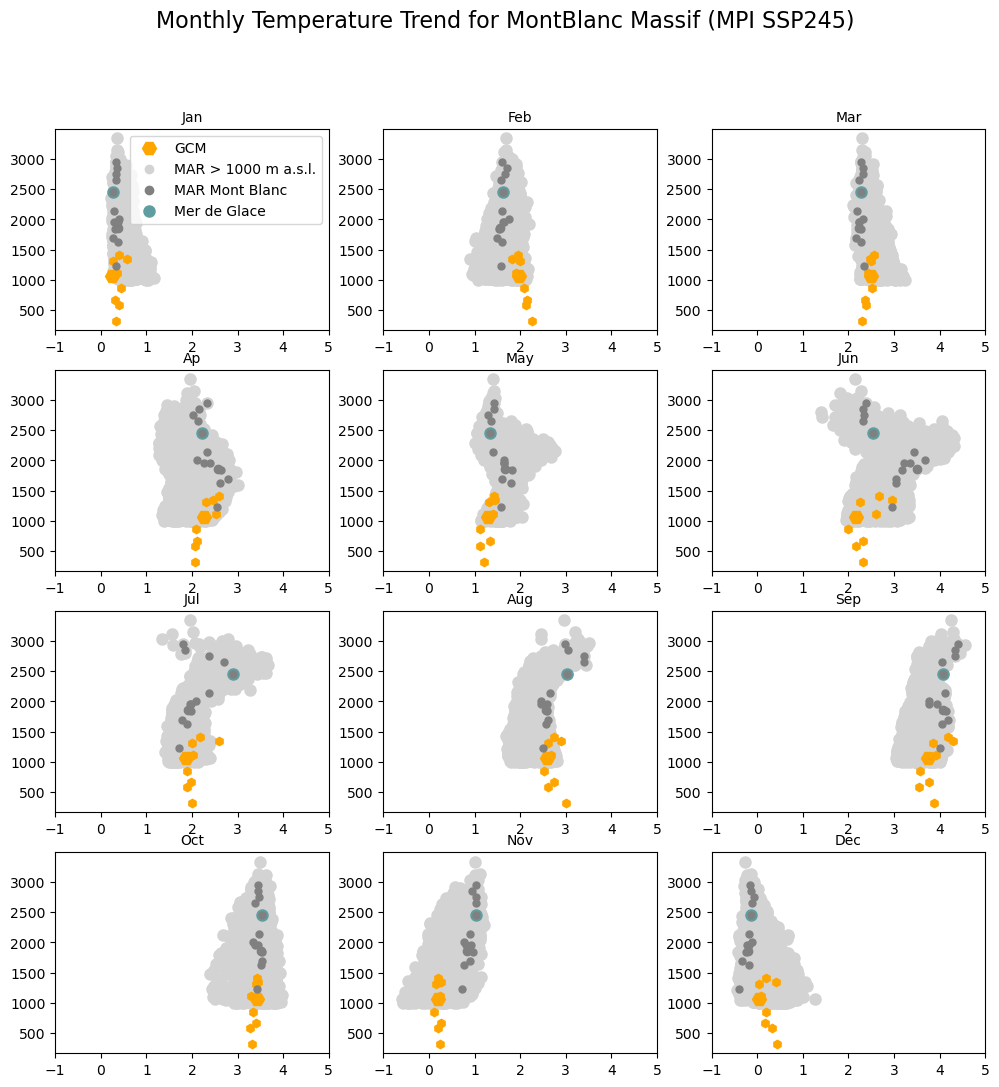

In [156]:
# Figure trend for all point in a massif
#For 1 glacier : Mont Blanc

fig, axs = plt.subplots(4, 3, figsize=(12, 12))
axs.ravel()

#m = 0 # months

for m, ax in enumerate(fig.axes):
    print(m,labelmonths[m])
    ax.set_title(labelmonths[m], fontsize=10)
    
    # MAR
    # French Alps
    for ii in range(20,80):
        for jj in range(10,110):
            if topoMAR[ii, jj] >=1000:
                ax.plot(100*slopeT_mM[m,ii,jj],topoMAR[ii,jj],'o',ms=8,color='lightgrey')
    
    # GCM  
    ax.plot(100*MBTtrend_monG[m], topoGCM[ylatG,xlonG],'H',color='orange', ms=10,label='GCM')  # !!!!!!! # !!!!!!!
    #neighbor points
    ax.plot(100*slopeT_mG[m,ylatG-1,xlonG-1], topoGCM[ylatG-1,xlonG-1],color='orange',marker='h')
    ax.plot(100*slopeT_mG[m,ylatG-1,xlonG],   topoGCM[ylatG-1,xlonG],  color='orange',marker='h')
    ax.plot(100*slopeT_mG[m,ylatG-1,xlonG+1], topoGCM[ylatG-1,xlonG+1],color='orange',marker='h')

    ax.plot(100*slopeT_mG[m,ylatG,xlonG-1],   topoGCM[ylatG,xlonG-1],color='orange',marker='h')
    ax.plot(100*slopeT_mG[m,ylatG,xlonG+1],   topoGCM[ylatG,xlonG+1],color='orange',marker='h')

    ax.plot(100*slopeT_mG[m,ylatG+1,xlonG-1], topoGCM[ylatG+1,xlonG-1],color='orange',marker='h')
    ax.plot(100*slopeT_mG[m,ylatG+1,xlonG],   topoGCM[ylatG+1,xlonG],  color='orange',marker='h')
    ax.plot(100*slopeT_mG[m,ylatG+1,xlonG+1], topoGCM[ylatG+1,xlonG+1],color='orange',marker='h')
    
    # MAR #Mont Blanc
    ax.plot(100*MBTtrend_monM[m,0],topoMARMassif[0],'o',color='lightgrey',label='MAR > 1000 m a.s.l.')
    ax.plot(100*MBTtrend_monM[m,0],topoMARMassif[0],'o',color='grey',label='MAR Mont Blanc')  
        
    # Arg & MdG
    # ig for MdG defined above
    nameM, xM, yM = glacioClXYM[ig][0], glacioClXYM[ig][1],glacioClXYM[ig][2]
    #print(nameM, xM, yM,100*slopeT_mM[m,xM,yM],topoMAR[xM, yM])
    ax.plot(100*slopeT_mM[m,xM,yM],topoMAR[xM, yM],'o',ms=8,color='cadetblue',label=nameM)
    
    # Loop on all the point of the massif
    for pt in range(len(inside_points_ij)): 
        ax.plot(100*MBTtrend_monM[m,pt],topoMARMassif[pt],'o',color='grey',ms=5)
        
    ax.set_xlim(-1,5)
axs[0,0].legend(loc='upper right') 

fig.suptitle(f"Monthly {varnameLong} Trend for MontBlanc Massif ({GCMname} {scenario})", fontsize=16)
plt.savefig(f"{path_IMG}{GCMname}_{scenario}_{varnameShort}_MontBlancMassif_Trend_month.png")

In [157]:
print('Well done !')

Well done !
